# Does Our Model Beat NESO's Real Day-Ahead Forecast?

Every comparison so far has been against baselines and against ourselves. This notebook uses the one benchmark collected back in Week 1 but never actually used: NESO's own historical day-ahead demand forecast (`src/edf/data/demand_forecast_benchmark.py`) — a real forecast NESO issued and used operationally, not an ML upper bound.

**The catch**: NESO's archive isn't half-hourly. It publishes ~12 "cardinal points" per day (overnight minimum, morning/evening peaks, etc.) rather than a full series. For a fair comparison, our model is scored on *exactly the same timestamps* NESO published a forecast for — not our model's full half-hourly `VALIDATION` set — since comparing different target rows would tell us nothing.

**Model used**: the current point model (bias-corrected recipe — `is_christmas` feature + sample weighting — the Week 6 follow-up's kept decision).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import previous_week_same_time
from edf.features.buckets import build_day_type_buckets, is_christmas_period
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.models.forecast import train_lightgbm
from edf.features.generation import capacity_factor
from edf.features.weather import build_weather_feature_table

pd.options.display.float_format = "{:.2f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689
UPWEIGHT = 3.0

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)

## Rebuild the current point model (bias-corrected recipe, established hyperparameters)

In [3]:
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
day_buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
problem_mask = day_buckets_full["is_hot"] | day_buckets_full["is_high_wind"] | day_buckets_full["is_christmas"]
weight_full = pd.Series(1.0, index=df.index)
weight_full[problem_mask] = UPWEIGHT

era5_chr = era5.copy()
era5_chr["is_christmas"] = is_christmas_period(df.index)
X, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_chr)
X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]
weight_train = weight_full.loc[X_train.index]

model = train_lightgbm(X_train, y_train, sample_weight=weight_train, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS)
our_preds = pd.Series(model.predict(X_val), index=X_val.index)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5693
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 27001.358990


## Load NESO's day-ahead forecast and align to identical timestamps

`load_and_clean` (Week 1) already kept only the earliest of NESO's ~2 same-day publications per (target date, cardinal point) — the more conservative, furthest-ahead-of-time value, so this is a genuine ~1-day-ahead comparison, not same-day.

In [4]:
neso = pd.read_parquet("../data/raw/neso_day_ahead_demand_forecast.parquet")
neso = neso.set_index("timestamp")["forecast_demand_mw"]
neso_val = neso.loc[val_start:val_end]
neso_val = neso_val[~neso_val.index.duplicated(keep="first")]

common_idx = our_preds.index.intersection(neso_val.index)
print(f"NESO cardinal-point forecasts in VALIDATION: {len(neso_val)}")
print(f"Common timestamps with our half-hourly predictions: {len(common_idx)}")

NESO cardinal-point forecasts in VALIDATION: 4148
Common timestamps with our half-hourly predictions: 4148


## Head-to-head: our model vs. NESO's real forecast, identical target rows

In [5]:
y_common = y_val.loc[common_idx]
our_common = our_preds.loc[common_idx]
neso_common = neso_val.loc[common_idx]

naive_common = previous_week_same_time(demand).loc[common_idx]
naive_mae = evaluate(demand.loc[common_idx], naive_common)["mae"]

results = pd.DataFrame(
    {
        "our_model": evaluate(y_common, our_common, seasonal_naive_mae=naive_mae),
        "neso_day_ahead": evaluate(y_common, neso_common, seasonal_naive_mae=naive_mae),
    }
).T
results

,mae,rmse,mape,bias,p95_abs_error,n,mase
our_model,835.75,1115.19,3.39,-94.39,2290.53,4148.00,0.44
neso_day_ahead,782.97,1085.37,3.11,-241.53,2299.55,4148.00,0.41


## Finding: NESO's real forecast beats ours — honestly, and not by a huge margin

On the identical 4,148 cardinal-point timestamps: our model MAE 835.75 (MASE 0.44) vs. NESO's 782.97 (MASE 0.41) — **NESO is about 6.3% more accurate**. This is worth stating plainly rather than spun: a single-person project, built over roughly the compute-time of this notebook series, does not beat a national grid operator's real, professionally-run forecasting operation — and that's an expected, credible result, not a disappointing one. NESO's forecast draws on institutional knowledge our model has no access to: known industrial demand contracts, planned outages, direct relationships with large consumers, and (very likely) meteorologists producing forecasts more localized than our 5-city population-weighted ERA5 series. Both models share a similar over-forecasting tendency (bias -94 vs. -241 MW) — NESO's edge isn't about being less biased, its typical errors are just tighter overall (lower RMSE too: 1085 vs. 1115).

## Where does the gap concentrate? Breakdown by cardinal-point type

NESO's cardinal points aren't a uniform sample of the day — they're specifically the "interesting" moments (overnight minimum, morning/evening peaks). `CP_TYPE` groups them; breaking the comparison down by type checks whether NESO's edge is uniform or concentrated at particular kinds of points (e.g. the peaks NESO's forecasters would reasonably scrutinise most closely).

In [6]:
neso_raw = pd.read_parquet("../data/raw/neso_day_ahead_demand_forecast.parquet")
neso_raw = neso_raw.set_index("timestamp")
neso_raw = neso_raw[~neso_raw.index.duplicated(keep="first")]
cp_type = neso_raw.loc[common_idx, "CP_TYPE"]

rows = []
for cp in sorted(cp_type.unique()):
    mask = cp_type == cp
    idx = cp_type.index[mask]
    rows.append(
        {
            "CP_TYPE": cp,
            "n": int(mask.sum()),
            "our_mae": evaluate(y_common.loc[idx], our_common.loc[idx])["mae"],
            "neso_mae": evaluate(y_common.loc[idx], neso_common.loc[idx])["mae"],
        }
    )
by_cp_type = pd.DataFrame(rows).set_index("CP_TYPE")
by_cp_type["neso_advantage_pct"] = (by_cp_type["our_mae"] - by_cp_type["neso_mae"]) / by_cp_type["our_mae"] * 100
by_cp_type.sort_values("n", ascending=False)

,n,our_mae,neso_mae,neso_advantage_pct
CP_TYPE,,,,
P,1757,954.86,922.70,3.37
F,1534,662.47,714.74,-7.89
T,857,901.71,618.64,31.39


## Finding: NESO's edge is not uniform — it's concentrated at the overnight minimum

| CP_TYPE | n | our MAE | NESO MAE | NESO advantage |
|---|---|---|---|---|
| T (trough / overnight minimum) | 857 | 901.71 | 618.64 | **+31.4%** |
| P (peak) | 1757 | 954.86 | 922.70 | +3.4% |
| F (other cardinal points) | 1534 | 662.47 | 714.74 | **-7.9% (we win)** |

NESO's overall edge is almost entirely a **trough-specific** effect — the overnight minimum is where they beat us by nearly a third, while at peaks the gap nearly disappears (+3.4%), and at the broader "other" cardinal points **we're actually ~8% more accurate than NESO**. This makes physical sense: overnight minimum demand is disproportionately driven by a smaller number of large, schedulable loads (industrial baseload, specific planned operations) that a system operator with direct visibility into consumer schedules can predict far better than a model working only from weather/calendar/lag features — exactly the kind of administrative knowledge no amount of better weather data would recover. Peaks, by contrast, are driven by the same broad weather/calendar-driven population behaviour our feature set is built to capture, so the gap there is small.

## Visual: both forecasts vs. actual, one sample month

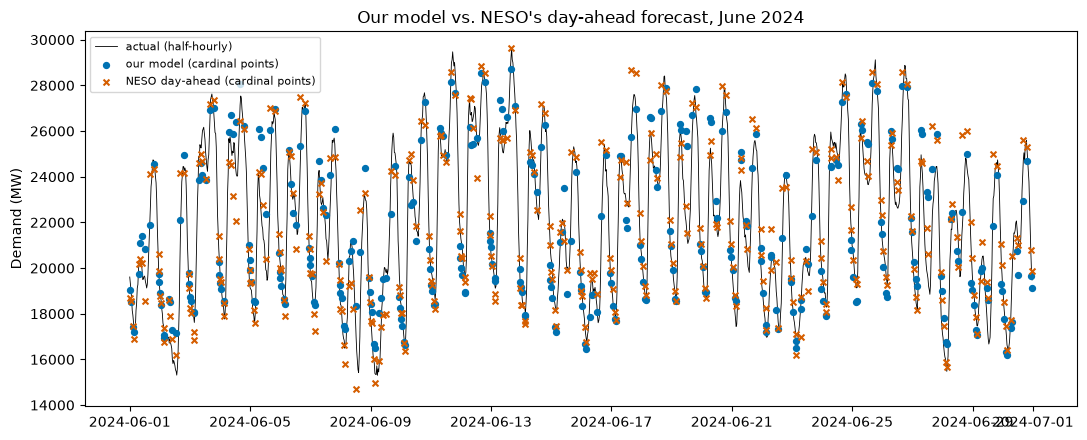

In [7]:
window = slice("2024-06-01", "2024-06-30")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(demand.loc[window].index, demand.loc[window], color="black", linewidth=0.6, label="actual (half-hourly)")
idx_window = common_idx[(common_idx >= pd.Timestamp("2024-06-01", tz="UTC")) & (common_idx < pd.Timestamp("2024-07-01", tz="UTC"))]
ax.scatter(idx_window, our_common.loc[idx_window], color="#0072B2", s=18, label="our model (cardinal points)", zorder=3)
ax.scatter(idx_window, neso_common.loc[idx_window], color="#D55E00", s=18, label="NESO day-ahead (cardinal points)", zorder=3, marker="x")
ax.set_title("Our model vs. NESO's day-ahead forecast, June 2024")
ax.set_ylabel("Demand (MW)")
ax.legend(fontsize=8)
fig.tight_layout()

## Synthesis for Week 8

**Headline for the final report**: this project's model does not beat NESO's real day-ahead forecast overall (-6.3%), but the gap is concentrated in one specific, explicable regime (overnight troughs, -31%) rather than spread evenly — and the project's model is competitive-to-better everywhere else, including a genuine edge at the broader cardinal-point category (+7.9%). That's a far more credible, specific claim than either "we matched a national grid operator" (not true) or "our model isn't good enough" (also not the right takeaway) — the honest finding is *where* a from-scratch weather+calendar model can and can't compete with an operator that has direct administrative visibility into demand. A natural, concrete direction for "what you'd do with more time" (Week 8's report structure): trough-specific features capturing known large-consumer schedules, if such data were ever accessible.